In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# 1. Create Time Series Data
t = np.linspace(0, 100, 500)
data = np.sin(t)

# Normalize
data = (data - np.mean(data)) / np.std(data)

In [3]:
# 2. Prepare Dataset
seq_length = 20

X = []
y = []

for i in range(len(data) - seq_length):
    X.append(data[i:i+seq_length])
    y.append(data[i+seq_length])

X = np.array(X)
y = np.array(y)

In [4]:
# Convert to tensors
X = torch.FloatTensor(X).unsqueeze(-1)  # (samples, seq_len, 1)
y = torch.FloatTensor(y)

# 3. Train/Test Split

train_size = int(0.8 * len(X))

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [5]:
# 4. LSTM Model
# ===============================
class LSTMModel(nn.Module):
    def __init__(self):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=64, batch_first=True)
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]   # last time step
        out = self.fc(out)
        return out.squeeze()

model = LSTMModel()

In [6]:
# 5. Loss & Optimizer

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

In [7]:
# 6. Training
# ===============================
epochs = 30

losses = []
all_preds = []

for epoch in range(epochs):
    model.train()

    optimizer.zero_grad()

    output = model(X_train)
    loss = criterion(output, y_train)

    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    all_preds.append(output.detach().numpy())

    # Detailed logging
    print(f"\nEpoch {epoch+1}/{epochs}")
    print("Input Sample:", X_train[0].flatten().numpy())
    print("Target:", y_train[0].item())
    print("Predicted:", output[0].item())
    print("Loss:", loss.item())


Epoch 1/30
Input Sample: [-1.2188824e-03  2.7990270e-01  5.4977202e-01  7.9758728e-01
  1.0134293e+00  1.1886587e+00  1.3162618e+00  1.3911312e+00
  1.4102699e+00  1.3729119e+00  1.2805527e+00  1.1368890e+00
  9.4767112e-01  7.2047269e-01  4.6438766e-01  1.8966614e-01
 -9.2695810e-02 -3.7139627e-01 -6.3527989e-01 -8.7378448e-01]
Target: -1.0773634910583496
Predicted: -0.013274814002215862
Loss: 0.991046130657196

Epoch 2/30
Input Sample: [-1.2188824e-03  2.7990270e-01  5.4977202e-01  7.9758728e-01
  1.0134293e+00  1.1886587e+00  1.3162618e+00  1.3911312e+00
  1.4102699e+00  1.3729119e+00  1.2805527e+00  1.1368890e+00
  9.4767112e-01  7.2047269e-01  4.6438766e-01  1.8966614e-01
 -9.2695810e-02 -3.7139627e-01 -6.3527989e-01 -8.7378448e-01]
Target: -1.0773634910583496
Predicted: -0.046669427305459976
Loss: 0.9199407696723938

Epoch 3/30
Input Sample: [-1.2188824e-03  2.7990270e-01  5.4977202e-01  7.9758728e-01
  1.0134293e+00  1.1886587e+00  1.3162618e+00  1.3911312e+00
  1.4102699e+00  

In [8]:
# 7. Evaluation
# ===============================
model.eval()

with torch.no_grad():
    test_preds = model(X_test)
    test_loss = criterion(test_preds, y_test)

print("\nTest Loss:", test_loss.item())


Test Loss: 0.0082083186134696


In [9]:
from sklearn.metrics import r2_score
print("R2 Score:", r2_score(y_test.numpy(), test_preds.numpy()))

R2 Score: 0.9917145371437073


In [11]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test.numpy(), test_preds.numpy()))
print("RMSE:", rmse)

RMSE: 0.09059977159722644


In [12]:
accuracy = (1 - rmse) * 100
print("Approx Accuracy (%):", accuracy)

Approx Accuracy (%): 90.94002284027735


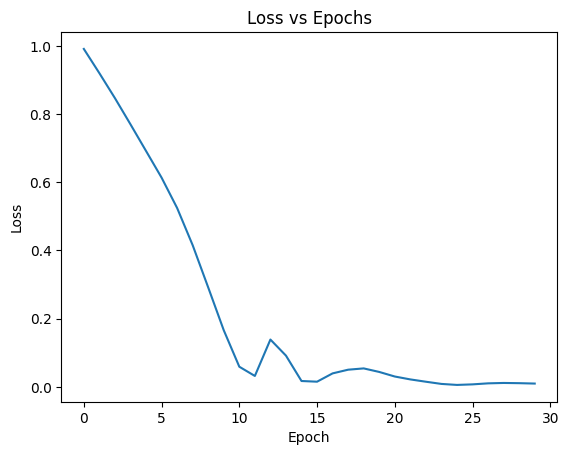

In [13]:
# 8. Graphs
# ===============================

# 1. Loss Curve
plt.figure()
plt.plot(losses)
plt.title("Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


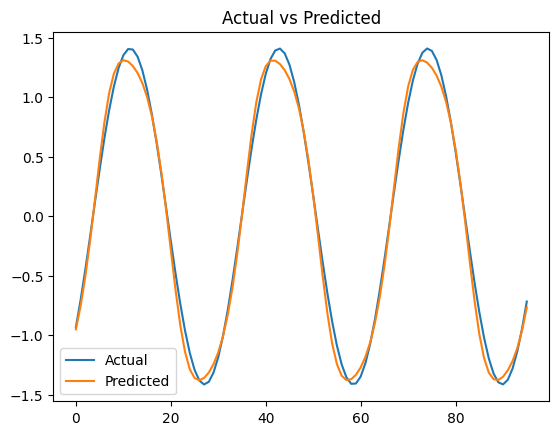

In [14]:
# 2. Actual vs Predicted
plt.figure()
plt.plot(y_test.numpy(), label="Actual")
plt.plot(test_preds.numpy(), label="Predicted")
plt.legend()
plt.title("Actual vs Predicted")
plt.show()

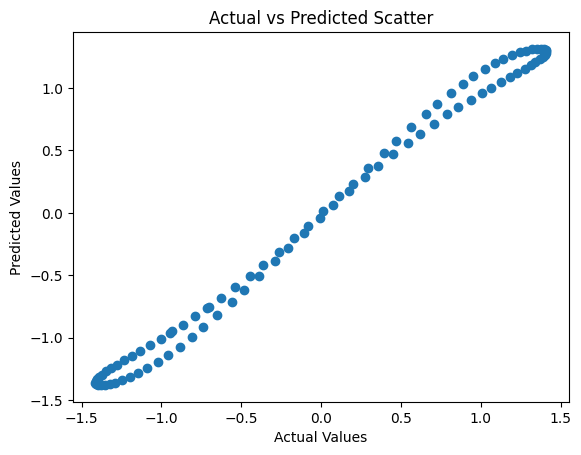

In [25]:
# 3. Actual vs Predicted Scatter Plot
plt.figure()
plt.scatter(y_true, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Scatter")
plt.show()

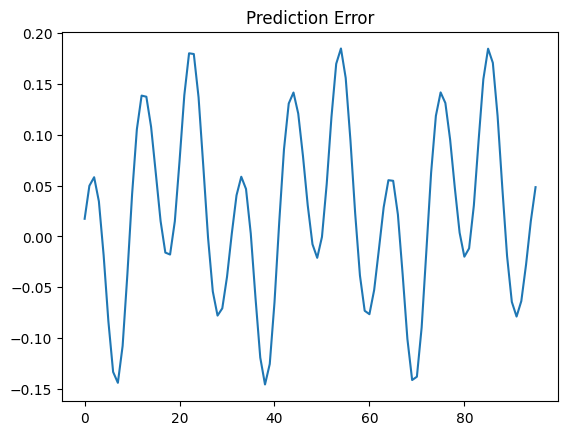

In [26]:
# 4. Error Plot
error = y_test.numpy() - test_preds.numpy()

plt.figure()
plt.plot(error)
plt.title("Prediction Error")
plt.show()

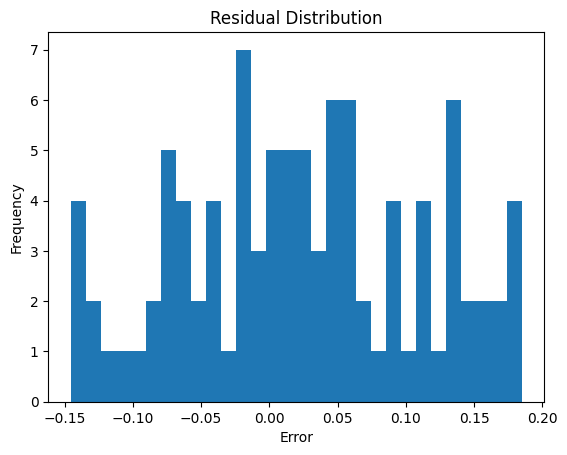

In [27]:
# 5. Residual Distribution
y_true = y_test.numpy()
y_pred = test_preds.numpy()
residuals = y_true - y_pred
plt.figure()
plt.hist(residuals, bins=30)
plt.title("Residual Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()


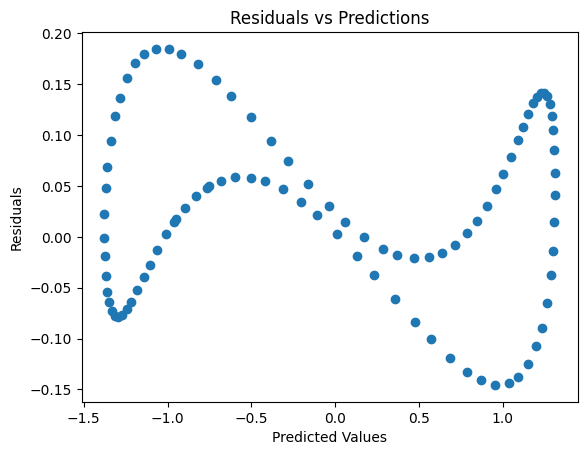

In [28]:
# 6. Residual vs Predictions
plt.figure()
plt.scatter(y_pred, residuals)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predictions")
plt.show()